# SGD Optimizer: Figures 18 And 19

This notebook was added for Appendix B.8. The corresponding W&B tag is `sgd-full-1layer`, which swaps AdamW for SGD while preserving the full one-layer transformer setup.


In [1]:
from analysis.utils import fetch_run_data, plot_combined_heads, plot_kl_divergence_simple, report_head_color_map
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
RUN_ID = "m0qjhj8n"
run_data = fetch_run_data(RUN_ID, metrics=["val_loss"])
cfg = run_data["config"]
pd.DataFrame(
    [{
        "run_id": RUN_ID,
        "name": run_data["name"],
        "tag": "sgd-full-1layer",
        "optimizer": cfg["optimizer"]["_target_"],
        "blocks": cfg["student"]["num_blocks"],
        "heads": cfg["student"]["num_heads"],
    }]
)


,run_id,name,tag,optimizer,blocks,heads
0,m0qjhj8n,ancient-planet-1877,sgd-full-1layer,torch.optim.SGD,1,3


## Figure 18: KL Divergence Under SGD

The KL curves show the same qualitative sequence of stages under SGD, with a longer training horizon.


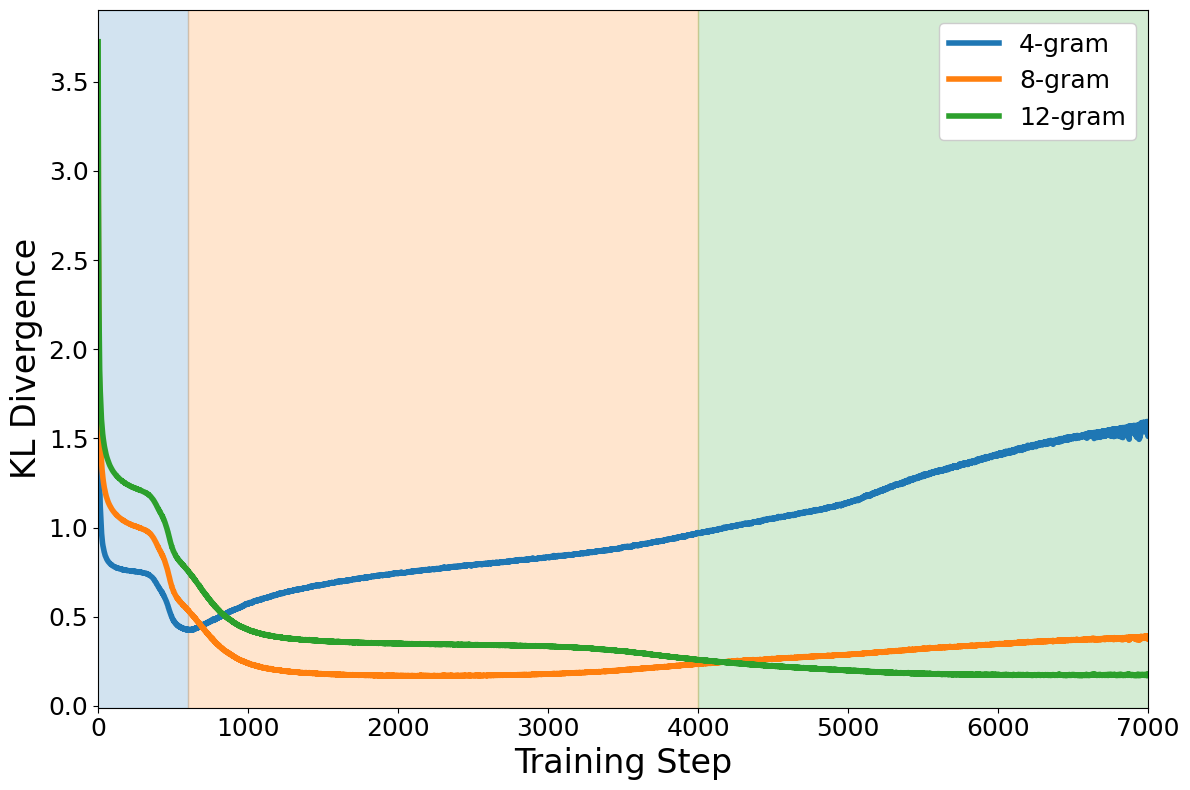

In [3]:
plot_kl_divergence_simple(
    run_id=RUN_ID,
    learnable=True,
    divergence_steps=[10600, 14000],
    max_steps=17000,
    shift_steps=10000,
    save_name=output_path("kl-sgd-full-1layer"),
)


## Figure 19: Attention Under SGD

The attention snapshots show the same competitive-to-cooperative specialization pattern under SGD.


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


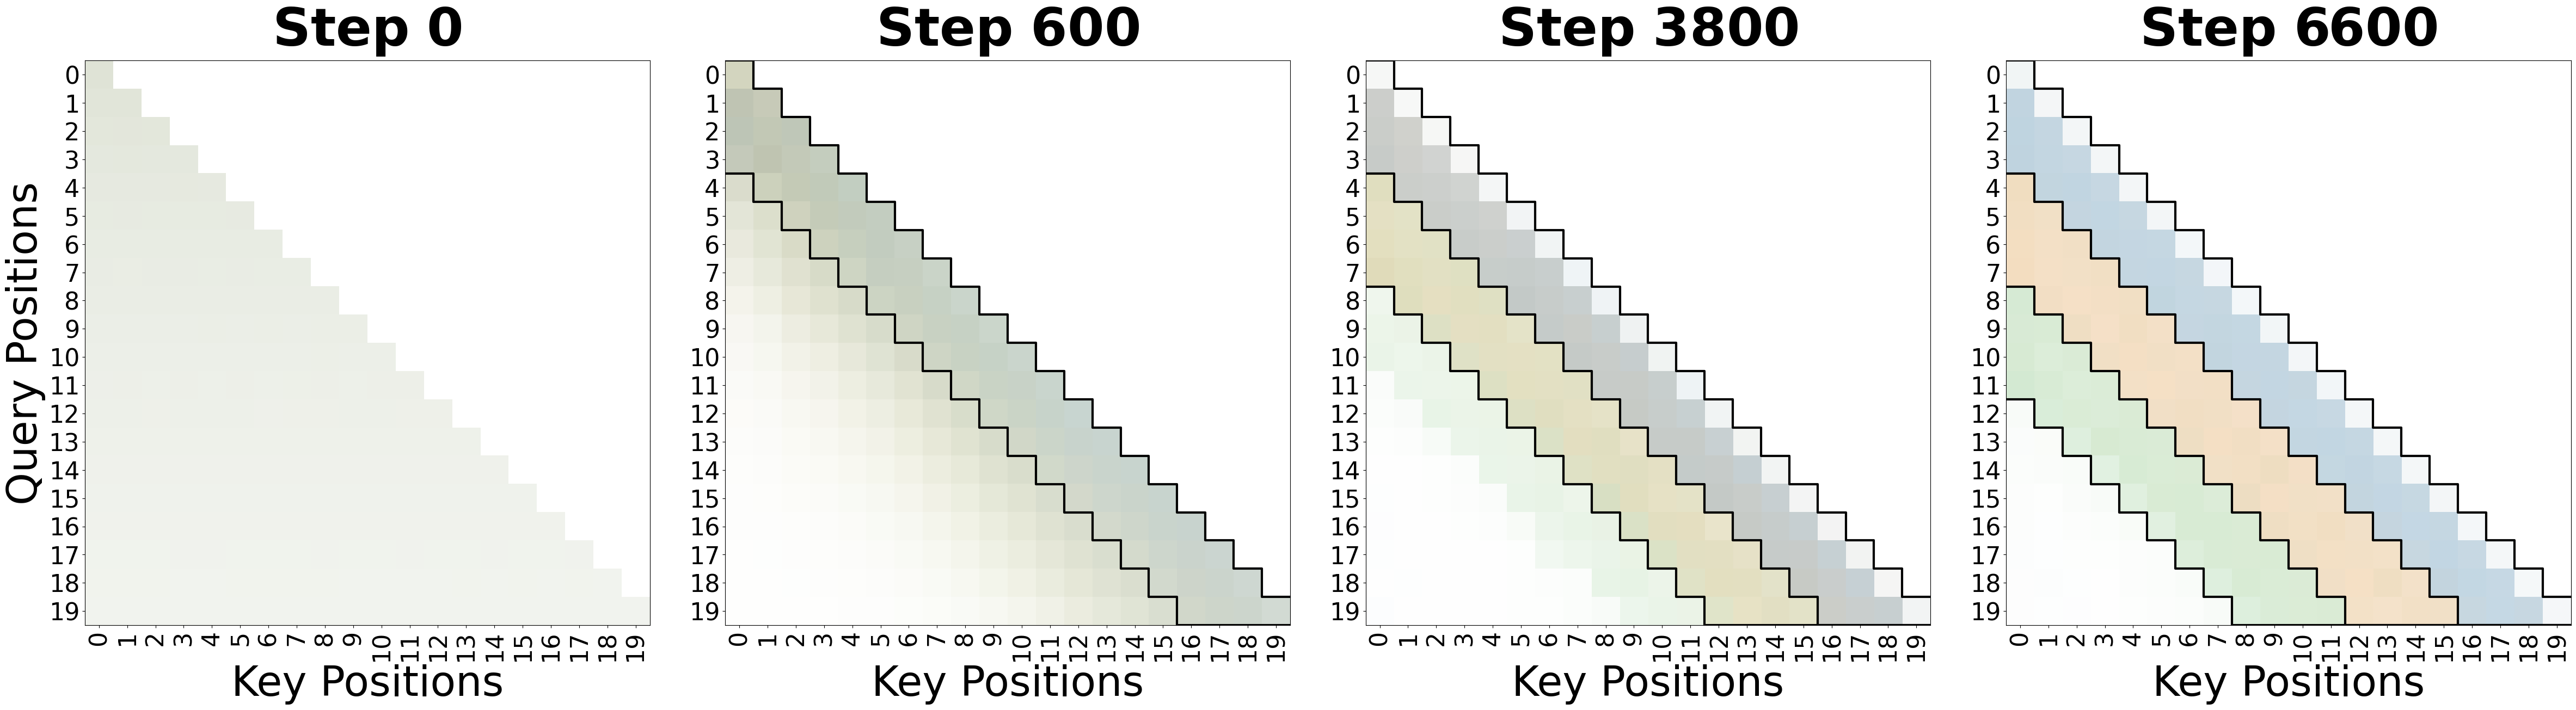

In [4]:
plot_combined_heads(
    RUN_ID,
    steps=[0, 600, 3800, 6600],
    frequency=200,
    split="val",
    head_colors=report_head_color_map([1, 2, 0]),
    staircases={1: [0, -4], 2: [0, -4, -8], 3: [0, -4, -8, -12]},
    save_name=output_path("attention-sgd-full-1layer"),
)
